# Análisis Exploratorio de Datos:
## Precios de Opciones (OptionMetrics)
Pablo Esparcia Casado


In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
from IPython.display import Markdown
# import gc
# gc.collect()


#------------------configuración y cargade datos ------------------

raw_df_clean = pd.read_parquet(r"C:\Users\pablo.esparcia\Documents\OptionMetrics\Descriptivos\opt_df.parquet")
opt_df = raw_df_clean

In [20]:
import psutil
vm = psutil.virtual_memory()
print(f"RAM total:      {vm.total / 1e9:.1f} GB")
print(f"RAM disponible: {vm.available / 1e9:.1f} GB")
print(f"RAM usada:      {vm.used / 1e9:.1f} GB")
print(f"% usado:        {vm.percent}%")

RAM total:      34.0 GB
RAM disponible: 16.9 GB
RAM usada:      17.1 GB
% usado:        50.3%


In [2]:
fp_df = pd.read_parquet(r"C:\Users\pablo.esparcia\Documents\OptionMetrics\Descriptivos\fp.parquet")
zc_df = pd.read_parquet(r"C:\Users\pablo.esparcia\Documents\OptionMetrics\Descriptivos\zc.parquet")

In [3]:
opt_df["Date"] = pd.to_datetime(opt_df["Date"], format="%Y-%m-%d")
opt_df["Expiration"] = pd.to_datetime(opt_df["Expiration"], format="%Y-%m-%d")
opt_df["Days"] = ((opt_df["Expiration"] - opt_df["Date"]).dt.days - opt_df["AMSettlement"])
opt_df["Strike"] = opt_df["Strike"]/1000
opt_df = opt_df[opt_df["ImpliedVolatility"] != -99.99]

opt_df["MidPrice"] = (opt_df["Bid"] + opt_df["Ask"]) / 2
opt_df["horquilla"] = (opt_df["Ask"] - opt_df["Bid"])/ opt_df["MidPrice"]


In [8]:

opt_bloque = []

for fecha, opt_fecha in opt_df.groupby("Date"):
   
    fp_fecha = fp_df[fp_df["Date"] == fecha]
    fp_fecha = fp_fecha.sort_values("Days")  
    if fp_fecha.empty:
        
        continue
    curva_fecha = zc_df[(zc_df["Date"] == fecha) & (zc_df["Currency"] == 333)]
    if curva_fecha.empty:
       
        continue
    opt_fecha["forward_index"] = np.interp(opt_fecha["Days"], fp_fecha["Days"], fp_fecha["ForwardPrice"])
    opt_fecha["Rate"] = interpolate_rates_surface(zc_df, opt_fecha, fecha, 333, 365)

    opt_bloque.append(opt_fecha)

opt_df_2 = pd.concat(opt_bloque, ignore_index=True)

opt_df_2["Moneyness"] = opt_df_2["Strike"] / opt_df_2["forward_index"]
opt_df_2["log_moneyness"] = np.log(opt_df_2["Moneyness"])
opt_df_2["flag_otm"] = (
    ((opt_df_2["CallPut"] == "P") & (opt_df_2["Moneyness"] <= 1)) |
    ((opt_df_2["CallPut"] == "C") & (opt_df_2["Moneyness"] >= 1))
)


Previsualización de las 5 primeras filas:

In [15]:
opt_df_2.head(5)

,SecurityID,OptionID,Date,Expiration,Strike,CallPut,Bid,Ask,Volume,OpenInterest,...,Vega,Theta,Days,MidPrice,horquilla,forward_index,Rate,Moneyness,log_moneyness,flag_otm
0,108105,20884382,2003-01-02,2003-01-18,810.0,C,98.4,100.4,2,1092,...,11.69511,-41.23674,15,99.4,0.020121,908.8181,0.013753,0.891267,-0.115111,False
1,108105,20876996,2003-01-02,2003-01-18,825.0,C,83.9,85.9,574,5527,...,18.02797,-65.00201,15,84.9,0.023557,908.8181,0.013753,0.907772,-0.096762,False
2,108105,20876997,2003-01-02,2003-01-18,850.0,C,60.3,62.3,352,3634,...,32.16503,-110.58680,15,61.3,0.032626,908.8181,0.013753,0.935281,-0.066909,False
3,108105,21377919,2003-01-02,2003-01-18,860.0,C,51.3,53.3,1,14,...,39.73530,-133.50640,15,52.3,0.038241,908.8181,0.013753,0.946284,-0.055213,False
4,108105,21349900,2003-01-02,2003-01-18,870.0,C,42.7,44.7,0,165,...,48.04552,-157.64410,15,43.7,0.045767,908.8181,0.013753,0.957287,-0.043652,False


## Descriptivos

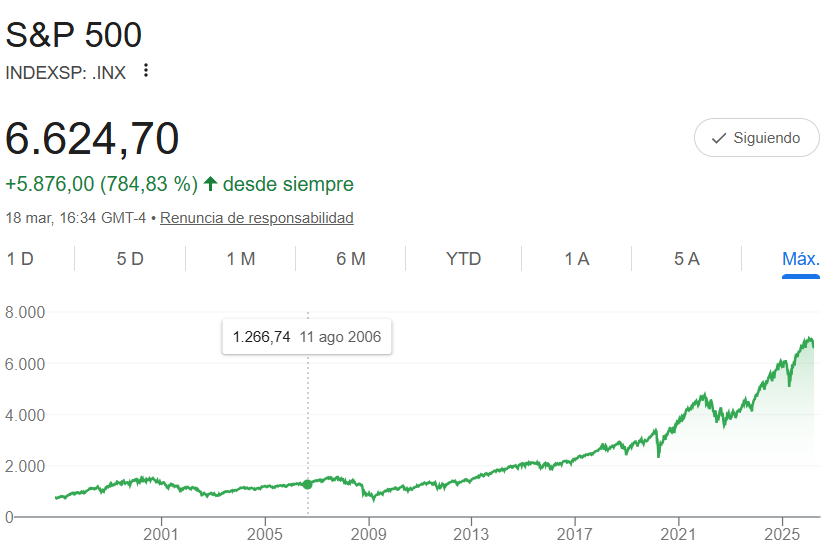

### Percentiles de Strike y Moneyness:

In [ ]:
desc_strike = opt_df_2['Strike'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_moneyness = opt_df_2['Moneyness'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_logm   = opt_df_2['log_moneyness'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])

pd.concat([desc_strike, desc_moneyness, desc_logm], axis=1).style.format("{:,.4f}")


In [ ]:
opt_df_2['Strike'].plot.hist(bins=np.arange(0, 12500, 50), figsize=(12, 5), edgecolor='black', color='paleturquoise')

plt.xlabel('Strike')
plt.ylabel('Frecuencia')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
opt_df_2['Moneyness'].plot.hist(bins=100, figsize=(12, 5), edgecolor='white', color='paleturquoise')
opt_df_2['log_moneyness'].plot.hist(bins=100, figsize=(12, 5), edgecolor='white', color='tomato',alpha =0.5, label = 'Log Moneyness')
plt.xlim(-3,3)
plt.xlabel('Moneyness')
plt.ylabel('Frecuencia')
plt.title('Distribución de Moneyness')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Número en bruto de opciones call y put:

In [ ]:
n_calls = (opt_df_2["CallPut"] == "C").sum()
n_puts  = (opt_df_2["CallPut"] == "P").sum()

print(f"Número de calls: {n_calls:,}")
print(f"Número de puts:  {n_puts:,}")
print(f"Relación P/C:    {100*(1-n_calls/n_puts):.4f}%")

#### Número de opciones Call y Put con strikes únicos:

In [ ]:
n_calls = opt_df_2[opt_df_2["CallPut"] == "C"]["Strike"].unique().sum()
n_puts  = opt_df_2[opt_df_2["CallPut"] == "P"]["Strike"].unique().sum()

print(f"Número de calls: {n_calls:,.0f}")
print(f"Número de puts:  {n_puts:,.0f}")
print(f"Relación P/C:    {100*(1-n_calls/n_puts):.4f}%")

In [ ]:
cmask = opt_df_2["CallPut"] == "C"

opt_df_2[cmask]['Moneyness'].plot.hist(bins=100, figsize=(12, 5), edgecolor='white', color='paleturquoise', label = 'Call')
opt_df_2[~cmask]['Moneyness'].plot.hist(bins=100, figsize=(12, 5), edgecolor='white', color='tomato',alpha =0.5, label = 'Put')
plt.xlim(-3,3)
plt.xlabel('Moneyness')
plt.ylabel('Frecuencia')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hay ligeramente más número de puts (4.8307%) que de calls, con calls con strikes más altos y puts con mayor densidad en strikes más bajos.
Con strikes repetidos eliminados, hay más cantidad de call que de puts, por lo que las puts tienen más contratos a distintos vencimientos que las calls.

### Descriptivos de precios:

In [22]:
desc_bid = opt_df_2['Bid'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_ask   = opt_df_2['Ask'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_mid   = opt_df_2['MidPrice'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])

pd.concat([desc_bid, desc_ask, desc_mid], axis=1).style.format("{:,.4f}")

,Bid,Ask,MidPrice
count,"34,244,379.0000","34,244,379.0000","34,244,379.0000"
mean,248.2221,251.9822,250.1021
std,439.0004,443.6627,441.3095
min,0.0000,0.0500,0.0250
1%,0.0000,0.0500,0.0250
5%,0.0000,0.1000,0.0750
10%,0.2000,0.4000,0.3000
25%,4.5000,5.0000,4.7500
50%,65.6000,67.4000,66.5000
75%,297.5000,303.2000,300.3500


### Filtros básicos del BID-ASK

Quito: Bid<0 (redundante) ; Bid>ASK


In [9]:

opt_df_2 = opt_df_2[(opt_df_2["Bid"]>=0) & (opt_df_2["Ask"] > opt_df_2["Bid"])]

MemoryError: Unable to allocate 523. MiB for an array with shape (2, 34244334) and data type float64

In [ ]:
desc_strike = filt_opt_df['Strike'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_mon = filt_opt_df['Moneyness'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_bid = filt_opt_df['Bid'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_ask   = filt_opt_df['Ask'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_oi  = filt_opt_df['OpenInterest'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_Volume  = filt_opt_df['Volume'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_days  = filt_opt_df['Days'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_horquilla  = filt_opt_df['horquilla'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])


pd.concat([desc_strike, desc_mon, desc_bid, desc_ask, desc_oi, desc_Volume, desc_days,desc_horquilla ], axis=1).style.format("{:,.4f}")

Se eliminan bajo estos filtros 45,000 puntos lo que no afecta en gran medida a la distribución de strikes.

### Vencimientos:

In [ ]:
(filt_opt_df['Days']).astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]).to_frame().style.format("{:,.4f}")

### Strikes y Moneyness agrupando por vencimiento

Agrupando por Deciles se obienen los siguientes estadísticos descriptivos para el **Strike**:

In [ ]:

labels=['D1','D2','D3','D4','D5','D6','D7','D8','D9','D10']
filt_opt_df['Days_bin'] = pd.qcut(filt_opt_df['Days'], q=10, labels = labels)


filt_opt_df.groupby('Days_bin',observed=True)['Strike'].describe(
    percentiles=[.05, .25, .50, .75, .95]
).style.format("{:,.0f}")

Gráfico BoxPlot del **Moneyness** categorizando el vencimiento en deciles :

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

groups = [filt_opt_df[filt_opt_df['Days_bin'] == label]['Moneyness'].dropna()
          for label in labels]

ax.boxplot(groups, tick_labels=labels, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='tomato', linewidth=2),
           flierprops=dict(marker='.', markersize=1, alpha=0.2))

ax.set_xlabel('Vencimiento', fontsize=12)
ax.set_ylabel('Moneyness', fontsize=12)
ax.set_title('Distribución de Moneyness por plazo de vencimiento', fontsize=13)
ax.axhline(1, color='black', linestyle='--', linewidth=0.8, label='ATM')
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

En lugar de cortes en conjuntos equivalentes, se muestran los descriptivos de **Strikes** cortando por fechas específicas:

In [ ]:
bins   = [0, 7, 14, 30, 45, 60, 90, 120, 180, 270, 365, np.inf]
labels = ['<1W', '1-2W', '2W-1M', '1-1.5M', '1.5-2M', '2-3M', '3-4M', '4-6M', '6-9M', '9-12M', '>12M']

filt_opt_df['Days_bin'] = pd.cut(filt_opt_df['Days'], bins=bins, labels=labels)

filt_opt_df.groupby('Days_bin',observed = True)['Strike'].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]
).style.format("{:,.2f}")

Y los estadísticos de **moneyness**:

In [ ]:
bins   = [0, 7, 14, 30, 45, 60, 90, 120, 180, 270, 365, np.inf]
labels = ['<1W', '1-2W', '2W-1M', '1-1.5M', '1.5-2M', '2-3M', '3-4M', '4-6M', '6-9M', '9-12M', '>12M']

filt_opt_df['Days_bin'] = pd.cut(filt_opt_df['Days'], bins=bins, labels=labels)

filt_opt_df.groupby('Days_bin',observed = True)['Moneyness'].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]
).style.format("{:,.2f}")

Visualización de gráficos de violín para ver la distribución del Moneyness entre Puts y Calls categorizando por vencimiento:

In [ ]:
g = sns.catplot(
    data=filt_opt_df, x='Days_bin', y='Moneyness', hue='CallPut',
    kind='violin', bw_adjust=.5, cut=0, split=True,
    order=labels, palette={'C': 'steelblue', 'P': 'tomato'},
    height=6, aspect=2.5
)

g.ax.axhline(1, color='black', linestyle='--', linewidth=0.8, label='ATM')
g.ax.set_title('Distribución de Moneyness por plazo y tipo', fontsize=13)
g.ax.tick_params(axis='x', rotation=45)
g.ax.set_xlabel('Vencimiento', fontsize=12)
g.ax.set_ylabel('Moneyness', fontsize=12)
plt.tight_layout()
plt.show()

Hagamos zoom al boxplot:

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(16, 6))

sns.boxplot(data=filt_opt_df, x='Days_bin', y='Moneyness',
            hue='CallPut', order=labels,
            palette={'C': 'steelblue', 'P': 'tomato'},
            showfliers=False,  # con 34M filas los fliers saturan
            width=0.6, gap=0.1,
            ax=ax)

ax.axhline(1, color='black', linestyle='--', linewidth=0.8, label='ATM')
ax.set_xlabel('Vencimiento', fontsize=12)
ax.set_ylabel('Moneyness', fontsize=12)
ax.legend(title='Tipo', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

La distribución de moneyness transita de leptocúrtica a mesocúrtica al aumentar el vencimiento, reflejando que el mercado cotiza opciones en un rango de strikes progresivamente más amplio conforme crece el horizonte temporal.

La dispersión del moneyness crece de forma robusta y monótona con el vencimiento, resultado que se mantiene independientemente de si la agrupación se realiza por deciles o por de tiempo con mayor información económica (días) — descartando así un artefacto de discretización. Los outliers extremos se concentran de forma desproporcionada en los vencimientos más largos (>6M).

Asimismo, parece que la distribución es relativamente simétrica.

Controlando por vencimientos, se aprecia un RIC desplazado hacia abajo para puts. Manteniendo el valor máximo de Moneyness similar al de las calls, y el mínimo ligeramente más bajo, por lo que se observa una mediana de moneyness más baja en put que en calls para todos los vencimientos.

### ¿Cómo es la horquilla de liquidez?

In [ ]:

filt_opt_df['horquilla'].plot.hist(bins=100, figsize=(12, 5), edgecolor='black', color='paleturquoise')

plt.xlabel('Horquilla')
plt.ylabel('Frecuencia')
plt.title('Distribución de Horquilla (SPX 2003–2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Veamos la relación de las horquillas categorizadas con los strikes:

In [ ]:

labels=['D1','D2','D3','D4','D5','D6','D7','D8','D9','D10']
filt_opt_df['horquilla_bins'] = pd.qcut(filt_opt_df['horquilla'], q=10, labels = labels)

filt_opt_df.groupby('horquilla_bins',observed=True)['Strike'].describe(percentiles=[0.1, .05, .25, .50, .75, .95, .99]).style.format("{:,.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.set_title('Media de Moneyness por categorías de Horquillas', fontsize=13)

pivot = (filt_opt_df.groupby(['horquilla_bins', 'CallPut'], observed=True)['Moneyness']
         .mean().unstack())

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=1, ax=ax, linewidths=0.5)
plt.show()

Parece que hay un patrón monótono decreciente para el caso de calls entre la liquidez medida por la horquilla y moneyness, y creciente para puts.

### Porcentaje de dias de negociación de cada contrato por mes:

In [ ]:

trading_days = (filt_opt_df.groupby(pd.Grouper(key='Date', freq='ME'))['Date'].nunique().rename('trading_days_mes'))

days_per_contract = (filt_opt_df.groupby(['OptionID', pd.Grouper(key='Date', freq='ME')])['Date'].nunique().rename('days_traded').reset_index())
    
days_per_contract = days_per_contract.merge(trading_days, on='Date')
days_per_contract['pct_days_traded'] = (days_per_contract['days_traded'] / days_per_contract['trading_days_mes'] * 100)

days_per_contract.head(10)

In [ ]:

pct_summary = (days_per_contract.groupby('OptionID')['pct_days_traded']
               .mean()
               .reset_index()
               .rename(columns={'pct_days_traded': 'pct_medio'}))

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Análisis negociación por contrato', fontsize=14)
gs  = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])  

# 1. Histograma
ax1.hist(pct_summary['pct_medio'], bins=50, color='steelblue', edgecolor='white')
ax1.set_xlabel('% trading days (average)', fontsize=11)
ax1.set_ylabel('Nº Contracts', fontsize=11)
ax1.set_title('Distribution of the average % of trading days', fontsize=12)
ax1.axvline(50, color='tomato', linestyle='--', label='50%')
ax1.xaxis.set_major_locator(MultipleLocator(10))   
ax1.xaxis.set_minor_locator(MultipleLocator(5))   
ax1.grid(True, alpha=0.3)  
ax1.legend()

# 2. CDF
sorted_pct = pct_summary['pct_medio'].sort_values()
ax2.plot(sorted_pct.values, np.linspace(0, 100, len(sorted_pct)), color='steelblue', linewidth=2)
ax2.axvline(np.median(pct_summary['pct_medio']), color='tomato', linestyle='--', label='Mediana')
ax2.set_xlabel('% días negociados (media)', fontsize=11)
ax2.set_ylabel('% contratos acumulado', fontsize=11)
ax2.set_title('CDF del % de días negociados', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Evolución temporal
monthly_avg = (days_per_contract.groupby('Date')['pct_days_traded']
               .mean().reset_index())
ax3.plot(monthly_avg['Date'], monthly_avg['pct_days_traded'], color='steelblue', linewidth=1)
ax3.set_xlabel('Fecha', fontsize=11)
ax3.set_ylabel('% días negociados (media)', fontsize=11)
ax3.set_title('Evolución temporal del % medio', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.xaxis.set_major_locator(mdates.YearLocator())  
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

¿Cuales son los strikes y moneyness de estos contratos?

In [ ]:


opt_contr_100 = filt_opt_df[filt_opt_df['OptionID'].isin(
    pct_summary[pct_summary["pct_medio"]>=90]["OptionID"])]

desc_strike = opt_contr_100['Strike'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_mon = opt_contr_100['Moneyness'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_days   = opt_contr_100['Days'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])

pd.concat([desc_strike, desc_mon, desc_days], axis=1).style.format("{:,.4f}")


In [ ]:

n = pct_summary[pct_summary["pct_medio"]>=90]["OptionID"].count()

display(Markdown(f"""
Tenemos por lo tanto aproximadamente **{n:,}** contratos que están al menos el 90% 
de los días de negociación. Pero lo realmente relevante, ya que es necesario hacer 
un rollover por strike es tener una relación uniforme de strike(moneyness)-vencimiento:
"""))

Agrupando por intervalos moneyness y vencimiento en días creo contratos que he llamado ficticios. Luego asigno cada punto de los datos a uno de estos contratos en base a su cercanía.
Por lo que no es una asingación exacta. Esto creo que está bien para luego estandarizar vencimientos

In [ ]:

cols = ['Date', 'Moneyness', 'Days']
df = filt_opt_df[cols].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['Date', 'Moneyness', 'Days']).copy()

# Nodos objetivo
m_min, m_max = df['Moneyness'].min(), df['Moneyness'].max()
d_min, d_max = df['Days'].min(),      df['Days'].max()

m_min, m_max = 0.1 , 1.91
d_min, d_max = 10 , 328


target_moneyness = np.linspace(m_min, m_max, 20)
target_days      = np.linspace(d_min, d_max, 20)

# Asignación al nodo más cercano
m_edges = np.concatenate(([-np.inf], (target_moneyness[:-1] + target_moneyness[1:]) / 2, [np.inf]))
m_idx   = pd.cut(df['Moneyness'], bins=m_edges, labels=False, include_lowest=True).astype(int)
df['m_target'] = target_moneyness[m_idx]

d_edges = np.concatenate(([-np.inf], (target_days[:-1] + target_days[1:]) / 2, [np.inf]))
d_idx   = pd.cut(df['Days'], bins=d_edges, labels=False, include_lowest=True).astype(int)
df['d_target'] = target_days[d_idx]

df['m_dist'] = (df['Moneyness'] - df['m_target']).abs()
df['d_dist'] = (df['Days']      - df['d_target']).abs()
df['contract_ficticio'] = 'M=' + df['m_target'].astype(str) + '|T=' + df['d_target'].astype(int).astype(str)

# Días de trading por mes
trading_days_month = (
    df.groupby(pd.Grouper(key='Date', freq='ME'))['Date']
      .nunique()
      .rename('trading_days_mes')
      .reset_index()
)

# Días negociados por nodo y mes
days_per_cf = (
    df.groupby(['contract_ficticio', 'm_target', 'd_target', pd.Grouper(key='Date', freq='ME')])['Date']
      .nunique()
      .rename('days_traded')
      .reset_index()
)
days_per_cf = days_per_cf.merge(trading_days_month, on='Date', how='left')
days_per_cf['pct_days_traded'] = 100 * days_per_cf['days_traded'] / days_per_cf['trading_days_mes']

# Densidad diaria
obs_per_day = (
    df.groupby(['contract_ficticio', 'Date'])
      .size()
      .rename('n_obs')
      .reset_index()
)
density_summary = (
    obs_per_day.groupby('contract_ficticio')['n_obs']
               .agg(mean_obs_day='mean', median_obs_day='median', std_obs_day='std')
               .reset_index()
)

# Resumen final
pct_summary = (
    days_per_cf.groupby(['contract_ficticio', 'm_target', 'd_target'])['pct_days_traded']
               .agg(pct_medio='mean', pct_min='min', pct_std='std')
               .reset_index()
)
summary = pct_summary.merge(density_summary, on='contract_ficticio')

# print(f"Contratos únicos: {len(summary)}")
# print(f"\nEstadísticos globales:")
# print(summary[['pct_medio', 'pct_min', 'mean_obs_day', 'median_obs_day']].describe().round(2))

# print(f"\nContratos con pct_medio < 50%:")
# print(summary[summary['pct_medio'] < 50][
#     ['contract_ficticio', 'pct_medio', 'pct_min', 'mean_obs_day']
# ].sort_values('pct_medio').to_string())

# print(f"\nContratos con pct_medio > 50%:")
# print(summary[summary['pct_medio'] >= 50][
#     ['contract_ficticio', 'pct_medio', 'pct_min', 'mean_obs_day']
# ].sort_values('pct_medio').to_string())

# print(f"\nTop 10 contratos más Negociados respecto a los días negociados:")
# print(summary.nlargest(10, 'pct_medio')[
#     ['contract_ficticio', 'pct_medio', 'mean_obs_day', 'median_obs_day']
# ].to_string())

# print(f"\nTop 10 contratos más densos (obs/día):")
# print(summary.nlargest(10, 'mean_obs_day')[
#     ['contract_ficticio', 'pct_medio', 'mean_obs_day', 'median_obs_day']
# ].to_string())


In [ ]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Coverage analysis using a fictitious contract', fontsize=14)
gs  = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])  
ax2 = fig.add_subplot(gs[1, :]) 


summary_50 = summary[summary['pct_medio']>=0].copy()
summary_50['d_target'] = summary_50['d_target'].round(0).astype(int)
summary_50['m_target'] = summary_50['m_target'].round(3)


pivot = summary_50.pivot_table(
    index='m_target', columns='d_target', values='pct_medio'
)

sns.heatmap(pivot, ax=ax1, cmap='RdYlGn', center=75,
            annot=True, fmt='.0f', linewidths=0.3,
            cbar_kws={'label': '% días negociados'})
ax1.set_title('% days traded per node moneyness - maturiry', fontsize=12)
ax1.set_xlabel('Maturity (days)', fontsize=11)
ax1.set_ylabel('Moneyness', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)
ax1.xaxis.set_tick_params(labelbottom=True)  


pivot_obs = summary_50.pivot_table(index='m_target', columns='d_target', values='mean_obs_day')

sns.heatmap(pivot_obs, ax=ax2, cmap='Blues',
            annot=True, fmt='.0f', linewidths=0.3,
            cbar_kws={'label': 'Obs/día (media)'})
ax2.set_title('Average density of observations per day', fontsize=12)
ax2.set_xlabel('Maturity (days)', fontsize=11)
ax2.set_ylabel('Moneyness', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)
ax2.xaxis.set_tick_params(labelbottom=True)  


plt.tight_layout()
plt.show()

Debería notarse que por la manera en la que he organizado los intervalos de vencimiento, tengo más granularidad al principio dentro del año, y para no tener muchisimos intervalos he agrupado los ultimos vencimientos (25% más alto) a intervalo 328.

In [ ]:
# Añadir las columnas de nodo al dataframe original
filt_opt_df['m_target'] = target_moneyness[
    pd.cut(filt_opt_df['Moneyness'], bins=m_edges, labels=False, include_lowest=True).astype(int)
]

filt_opt_df['d_target'] = target_days[
    pd.cut(filt_opt_df['Days'], bins=d_edges, labels=False, include_lowest=True).astype(int)
]

filt_opt_df['m_target'] = filt_opt_df['m_target'].round(3)
filt_opt_df['d_target'] = filt_opt_df['d_target'].round(0).astype(int)

filt_opt_df['contract_ficticio'] = (
    'M=' + filt_opt_df['m_target'].astype(str) +
    '|T=' + filt_opt_df['d_target'].astype(str)
)

In [ ]:
#ejemplo:
contratos_validos = summary[summary['pct_medio'] >= 50]['contract_ficticio'].tolist()
filt_opt_df_clean = filt_opt_df[filt_opt_df['contract_ficticio'].isin(contratos_validos)]

### Veamos ahora los estadísticos principales de las variables OI y Volumen:

In [ ]:

desc_oi = filt_opt_df['OpenInterest'].astype(int).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_vol = filt_opt_df['Volume'].astype(int).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])

pd.concat([desc_oi, desc_vol], axis=1).style.format("{:,.2f}")


Visualización de de la serie temporal:

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Evolución temporal del mercado SPX 2003–2024', fontsize=14, fontweight='bold')

# ── Paleta ──────────────────────────────────────────────────────────────────
c_call, c_put = '#4a9eda', '#e07b54'

# ── Agregación mensual ───────────────────────────────────────────────────────
monthly = (
    filt_opt_df
    .groupby([pd.Grouper(key='Date', freq='ME'), 'CallPut'])
    .agg(
        Volume       = ('Volume',       'sum'),
        OpenInterest = ('OpenInterest', 'sum'),
        n_contratos  = ('OptionID',     'nunique')
    )
    .reset_index()
)

calls = monthly[monthly['CallPut'] == 'C'].set_index('Date')
puts  = monthly[monthly['CallPut'] == 'P'].set_index('Date')

# ── Panel 1: Número de contratos únicos ─────────────────────────────────────
axes[0].plot(calls.index, calls['n_contratos'], color=c_call, lw=1.2, label='Call')
axes[0].plot(puts.index,  puts['n_contratos'],  color=c_put,  lw=1.2, label='Put')
axes[0].set_title('Número de contratos únicos (OptionID)', fontsize=11)
axes[0].set_ylabel('Contratos')
axes[0].legend(frameon=False)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# ── Panel 2: Volumen total ───────────────────────────────────────────────────
axes[1].fill_between(calls.index, calls['Volume'], alpha=0.4, color=c_call, label='Call')
axes[1].fill_between(puts.index,  puts['Volume'],  alpha=0.4, color=c_put,  label='Put')
axes[1].plot(calls.index, calls['Volume'], color=c_call, lw=0.8)
axes[1].plot(puts.index,  puts['Volume'],  color=c_put,  lw=0.8)
axes[1].set_title('Volumen mensual', fontsize=11)
axes[1].set_ylabel('Contratos negociados')
axes[1].legend(frameon=False)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# ── Panel 3: Open Interest ───────────────────────────────────────────────────
axes[2].fill_between(calls.index, calls['OpenInterest'], alpha=0.4, color=c_call, label='Call')
axes[2].fill_between(puts.index,  puts['OpenInterest'],  alpha=0.4, color=c_put,  label='Put')
axes[2].plot(calls.index, calls['OpenInterest'], color=c_call, lw=0.8)
axes[2].plot(puts.index,  puts['OpenInterest'],  color=c_put,  lw=0.8)
axes[2].set_title('Open Interest mensual', fontsize=11)
axes[2].set_ylabel('Contratos abiertos')
axes[2].legend(frameon=False)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# ── Formato eje X compartido ─────────────────────────────────────────────────
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

# ── Eventos clave ────────────────────────────────────────────────────────────
eventos = {
    '2008-09': ('GFC', 'red'),
    '2020-03': ('COVID', 'orange'),
}
for fecha_str, (label, color) in eventos.items():
    fecha = pd.Timestamp(fecha_str)
    for ax in axes:
        ax.axvline(fecha, color=color, lw=1, linestyle='--', alpha=0.6)
    axes[0].text(fecha, axes[0].get_ylim()[1]*0.85, label,
                 color=color, fontsize=8, ha='center')

plt.tight_layout()
plt.show()

In [ ]:
mask_ambos_cero = (filt_opt_df['OpenInterest'] == 0) & (filt_opt_df['Volume'] == 0)

print(f"OI=0:              {(filt_opt_df['OpenInterest']==0).sum():,} ({100*(filt_opt_df['OpenInterest']==0).mean():.1f}%)")
print(f"Vol=0:             {(filt_opt_df['Volume']==0).sum():,} ({100*(filt_opt_df['Volume']==0).mean():.1f}%)")
print(f"OI=0 Y Vol=0:      {mask_ambos_cero.sum():,} ({100*mask_ambos_cero.mean():.1f}%)")
print(f"OI=0 O Vol=0:      {((filt_opt_df['OpenInterest']==0) | (filt_opt_df['Volume']==0)).sum():,}")

#### Comparemos la relación entre contratos reales (OptionID) con el volumen y OI:

¿En qué zona de moneyness y vencimiento están los OI=0 Y Vol=0?

In [ ]:
moneyness_bins  = [0.5, 0.7, 0.8, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.30, np.inf]
moneyness_labels = ['<0.7', '0.7-0.8', '0.8-0.85', '0.85-0.90', '0.90-0.95',
                    '0.95-1.00', '1.00-1.05', '1.05-1.10', '1.10-1.15', '1.15-1.20', '1.20-1.30', '>1.30']

filt_opt_df['moneyness_bin'] = pd.cut(filt_opt_df['Moneyness'], 
                                       bins=moneyness_bins, 
                                       labels=moneyness_labels)
total = filt_opt_df.groupby(['Days_bin', 'moneyness_bin'], observed=True).size().unstack()
cero = filt_opt_df[mask_ambos_cero].groupby(['Days_bin', 'moneyness_bin'], observed=True).size().unstack()

pct_eliminado = (cero / total * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Impact of the filter OI=0 & Vol=0 per surface zone', fontsize=14)


sns.heatmap(total/1000, ax=axes[0], cmap='Blues', annot=True, fmt='.0f', 
            linewidths=0.3, cbar_kws={'label': 'Nº obs'})
axes[0].set_title('Total observations (thousands)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)



# Matriz binaria: 1 si supera el umbral, 0 si no
# q = 0.30
# umbral = pct_eliminado.unstack().quantile(q) 


# binario = (pct_eliminado > umbral).astype(int)


# sns.heatmap(binario, ax=axes[2], 
#             annot=True, fmt='d', linewidths=0.3, cbar = False, cmap='RdYlGn_r')
# axes[2].set_title(f'Celdas con % eliminado > {umbral:.1f}% (Cuantil:{q})', fontsize=12)
# axes[2].tick_params(axis='x', rotation=45)


# 3. % eliminado
sns.heatmap(pct_eliminado, ax=axes[1], cmap='RdYlGn_r', center=20,
            annot=True, fmt='.1f', linewidths=0.3,
            cbar_kws={'label': '% removed'})
axes[1].set_title('% removed per cell', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

¿Cómo es la distribución de los contratos negociados con volumen y OI distinto a cero?

In [ ]:

temp = filt_opt_df[mask_ambos_cero]
trading_days = (temp.groupby(pd.Grouper(key='Date', freq='ME'))['Date'].nunique().rename('trading_days_mes'))

days_per_contract = (temp.groupby(['OptionID', pd.Grouper(key='Date', freq='ME')])['Date'].nunique().rename('days_traded').reset_index())
    
days_per_contract = days_per_contract.merge(trading_days, on='Date')
days_per_contract['pct_days_traded'] = (days_per_contract['days_traded'] / days_per_contract['trading_days_mes'] * 100)


pct_summary = (days_per_contract.groupby('OptionID')['pct_days_traded']
               .mean()
               .reset_index()
               .rename(columns={'pct_days_traded': 'pct_medio'}))

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Análisis negociación por contrato', fontsize=14)
gs  = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])  

# 1. Histograma
ax1.hist(pct_summary['pct_medio'], bins=50, color='steelblue', edgecolor='white')
ax1.set_xlabel('% días negociados (media)', fontsize=11)
ax1.set_ylabel('Nº contratos', fontsize=11)
ax1.set_title('Distribución del % medio de días negociados', fontsize=12)
ax1.axvline(50, color='tomato', linestyle='--', label='50%')
ax1.xaxis.set_major_locator(MultipleLocator(10))   
ax1.xaxis.set_minor_locator(MultipleLocator(5))   
ax1.grid(True, alpha=0.3)  
ax1.legend()

# 2. CDF
sorted_pct = pct_summary['pct_medio'].sort_values()
ax2.plot(sorted_pct.values, np.linspace(0, 100, len(sorted_pct)), color='steelblue', linewidth=2)
ax2.axvline(np.median(pct_summary['pct_medio']), color='tomato', linestyle='--', label='Mediana')
ax2.set_xlabel('% días negociados (media)', fontsize=11)
ax2.set_ylabel('% contratos acumulado', fontsize=11)
ax2.set_title('CDF del % de días negociados', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Evolución temporal
monthly_avg = (days_per_contract.groupby('Date')['pct_days_traded']
               .mean().reset_index())
ax3.plot(monthly_avg['Date'], monthly_avg['pct_days_traded'], color='steelblue', linewidth=1)
ax3.set_xlabel('Fecha', fontsize=11)
ax3.set_ylabel('% días negociados (media)', fontsize=11)
ax3.set_title('Evolución temporal del % medio', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.xaxis.set_major_locator(mdates.YearLocator())  
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()



Número, strike y moneyness de puntos tras filtrar:

In [ ]:

opt_contr_100 = temp[filt_opt_df['OptionID'].isin(
    pct_summary[pct_summary["pct_medio"]>=90]["OptionID"])]

desc_strike = opt_contr_100['Strike'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_mon = opt_contr_100['Moneyness'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_days   = opt_contr_100['Days'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])

pd.concat([desc_strike, desc_mon, desc_days], axis=1).style.format("{:,.4f}")

In [ ]:

n = pct_summary[pct_summary["pct_medio"]>=90]["OptionID"].count()

display(Markdown(f"""
Tenemos por lo tanto, **{n:,}** contratos que están al menos el 90% 
de los días de negociación."""))

¿Cuales son los contratos ficticios (agrupados) tras controlar por volumen distinto a cero?

In [ ]:

cols = ['Date', 'Moneyness', 'Days']
df = temp[cols].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['Date', 'Moneyness', 'Days']).copy()

# Nodos objetivo
m_min, m_max = df['Moneyness'].min(), df['Moneyness'].max()
d_min, d_max = df['Days'].min(),      df['Days'].max()

m_min, m_max = 0.1 , 1.91
d_min, d_max = 10 , 328


target_moneyness = np.linspace(m_min, m_max, 20)
target_days      = np.linspace(d_min, d_max, 20)

# Asignación al nodo más cercano
m_edges = np.concatenate(([-np.inf], (target_moneyness[:-1] + target_moneyness[1:]) / 2, [np.inf]))
m_idx   = pd.cut(df['Moneyness'], bins=m_edges, labels=False, include_lowest=True).astype(int)
df['m_target'] = target_moneyness[m_idx]

d_edges = np.concatenate(([-np.inf], (target_days[:-1] + target_days[1:]) / 2, [np.inf]))
d_idx   = pd.cut(df['Days'], bins=d_edges, labels=False, include_lowest=True).astype(int)
df['d_target'] = target_days[d_idx]

df['m_dist'] = (df['Moneyness'] - df['m_target']).abs()
df['d_dist'] = (df['Days']      - df['d_target']).abs()
df['contract_ficticio'] = 'M=' + df['m_target'].astype(str) + '|T=' + df['d_target'].astype(int).astype(str)

# Días de trading por mes
trading_days_month = (
    df.groupby(pd.Grouper(key='Date', freq='ME'))['Date']
      .nunique()
      .rename('trading_days_mes')
      .reset_index()
)

# Días negociados por nodo y mes
days_per_cf = (
    df.groupby(['contract_ficticio', 'm_target', 'd_target', pd.Grouper(key='Date', freq='ME')])['Date']
      .nunique()
      .rename('days_traded')
      .reset_index()
)
days_per_cf = days_per_cf.merge(trading_days_month, on='Date', how='left')
days_per_cf['pct_days_traded'] = 100 * days_per_cf['days_traded'] / days_per_cf['trading_days_mes']

# Densidad diaria
obs_per_day = (
    df.groupby(['contract_ficticio', 'Date'])
      .size()
      .rename('n_obs')
      .reset_index()
)
density_summary = (
    obs_per_day.groupby('contract_ficticio')['n_obs']
               .agg(mean_obs_day='mean', median_obs_day='median', std_obs_day='std')
               .reset_index()
)

# Resumen final
pct_summary = (
    days_per_cf.groupby(['contract_ficticio', 'm_target', 'd_target'])['pct_days_traded']
               .agg(pct_medio='mean', pct_min='min', pct_std='std')
               .reset_index()
)
summary = pct_summary.merge(density_summary, on='contract_ficticio')


In [ ]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Análisis de cobertura por contrato ficticio (SPX 2003–2024)', fontsize=14)
gs  = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])  
ax2 = fig.add_subplot(gs[1, :]) 


summary_50 = summary[summary['pct_medio']>=0].copy()
summary_50['d_target'] = summary_50['d_target'].round(0).astype(int)
summary_50['m_target'] = summary_50['m_target'].round(3)


pivot = summary_50.pivot_table(
    index='m_target', columns='d_target', values='pct_medio'
)

sns.heatmap(pivot, ax=ax1, cmap='RdYlGn', center=75,
            annot=True, fmt='.0f', linewidths=0.3,
            cbar_kws={'label': '% días negociados'})
ax1.set_title('% días negociados por nodo moneyness × vencimiento', fontsize=12)
ax1.set_xlabel('Vencimiento (días)', fontsize=11)
ax1.set_ylabel('Moneyness', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)
ax1.xaxis.set_tick_params(labelbottom=True)  


pivot_obs = summary_50.pivot_table(index='m_target', columns='d_target', values='mean_obs_day')

sns.heatmap(pivot_obs, ax=ax2, cmap='Blues',
            annot=True, fmt='.0f', linewidths=0.3,
            cbar_kws={'label': 'Obs/día (media)'})
ax2.set_title('Densidad media de observaciones por día', fontsize=12)
ax2.set_xlabel('Vencimiento (días)', fontsize=11)
ax2.set_ylabel('Moneyness', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)
ax2.xaxis.set_tick_params(labelbottom=True)  


plt.tight_layout()
plt.show()

## Análisis de volumen, actividad, y precios en conjunto:

In [ ]:

first_day_contract = filt_opt_df.loc[
    filt_opt_df.groupby('OptionID')['Days'].idxmax()
]
first_day_contract["Bid_D"]    = (first_day_contract["Bid"] != 0).astype(int)
first_day_contract["Ask_D"]    = (first_day_contract["Ask"] != 0).astype(int)
first_day_contract["BidAsk_D"] = ((first_day_contract["Bid"] != 0) & (first_day_contract["Ask"] != 0)).astype(int)
first_day_contract["Vol_Price"] = first_day_contract["Volume"] * first_day_contract["MidPrice"]

first_day_contract_30 = first_day_contract[first_day_contract['Days'] == 30].copy()
first_day_contract_30.columns

### A) Medias Pooled Cross-Sectional (agrupando el por bucket)

In [ ]:

d = 0.1
m_min = 0.1
m_max = 2
n =  int(m_max/d)

m_grid = np.linspace(0.1 , 2 , n)
m_edges = np.concatenate(([-np.inf], m_grid , [np.inf]))

m_idx   = pd.cut(first_day_contract_30['Moneyness'], bins=m_edges, labels= False, include_lowest = True)

first_day_contract_30["M_Interval"] =  m_edges[m_idx]

pd.cut(first_day_contract_30['Moneyness'], bins=m_edges, include_lowest = True).value_counts().sort_index()



In [ ]:
calls = first_day_contract_30[first_day_contract_30["CallPut"] == "C"].groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D","Vol_Price", "horquilla"]].mean()
puts  = first_day_contract_30[first_day_contract_30["CallPut"] == "P"].groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D","Vol_Price", "horquilla"]].mean()

calls_n = first_day_contract_30[first_day_contract_30["CallPut"] == "C"].groupby("M_Interval").size().rename("n_opciones")
puts_n  = first_day_contract_30[first_day_contract_30["CallPut"] == "P"].groupby("M_Interval").size().rename("n_opciones")

calls = calls.join(calls_n)
puts  = puts.join(puts_n)

pd.concat([calls, puts], axis=1, keys=["Call", "Put"])

In [ ]:


puts = (first_day_contract_30[first_day_contract_30["CallPut"] == "C"]
        .groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
        .mean())

m_labels   = puts.index.tolist()
horquilla  = puts["horquilla"].tolist()
bid_d      = puts["Bid_D"].tolist()
ask_d      = puts["Ask_D"].tolist()
bidask_d   = puts["BidAsk_D"].tolist()
volume     = puts["Volume"].tolist()
vol_price  = puts["Vol_Price"].tolist()
open_int   = puts["OpenInterest"].tolist()

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.3)

axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[0,2]),
        fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2]),
        fig.add_subplot(gs[2,0])]

datasets = [
    (horquilla, "horquilla",    "tab:blue"),
    (bid_d,     "Bid_D",        "tab:cyan"),
    (ask_d,     "Ask_D",        "tab:purple"),
    (bidask_d,  "BidAsk_D",     "tab:green"),
    (volume,    "volume",       "tab:orange"),
    (vol_price, "vol_price",    "tab:red"),
    (open_int,  "OpenInterest", "tab:brown"),
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.plot(m_labels, data, marker='o', color=color, linewidth=1.8, markersize=4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("moneyness (K/F)", fontsize=9)
    ax.set_xticks(m_labels)
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.grid(True, alpha=0.3)

plt.suptitle("Puts — promedio temporal cross-section τ=30 días", fontsize=13, y=1.01)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

calls = (first_day_contract_30[first_day_contract_30["CallPut"] == "C"]
         .groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
         .mean())
puts = (first_day_contract_30[first_day_contract_30["CallPut"] == "P"]
        .groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
        .mean())

ylim_volp = 200  # hardcodeado: outlier ~1000 en ATM

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (df, label) in enumerate([(calls, "Calls"), (puts, "Puts")]):

    m_labels  = df.index.tolist()
    horquilla = df["horquilla"].tolist()
    bid_d     = df["Bid_D"].tolist()
    ask_d     = df["Ask_D"].tolist()
    bidask_d  = df["BidAsk_D"].tolist()
    volume    = df["Volume"].tolist()
    vol_price = df["Vol_Price"].tolist()

    # Panel liquidez
    ax1  = axes[row, 0]
    ax1b = ax1.twinx()

    ax1.plot(m_labels, bid_d,      marker='o', color='tab:blue',   linewidth=2.5, markersize=5, label='Bid_D',    zorder=3)
    ax1.plot(m_labels, ask_d,      marker='s', color='tab:purple', linewidth=1.5, markersize=4, label='Ask_D',    zorder=2, linestyle=':')
    ax1.plot(m_labels, bidask_d,   marker='^', color='tab:green',  linewidth=1.0, markersize=3, label='BidAsk_D', zorder=1, linestyle='--')
    ax1b.plot(m_labels, horquilla, marker='D', color='tab:red',    linewidth=1.8, markersize=4, label='horquilla', linestyle='--')

    ax1.set_ylabel("Dummy", fontsize=9)
    ax1b.set_ylabel("Spread", color='tab:red', fontsize=9)
    ax1.set_ylim(0, 1.1)
    ax1.set_title(f"Quote Prices analysis — {label}", fontsize=11)
    ax1.set_xticks(m_labels)
    ax1.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax1.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    
    ax1.yaxis.set_minor_locator(plt.MultipleLocator(0.05))  # cada 0.05 en el eje de proporciones
    ax1.grid(True, which='minor', alpha=0.15)
    ax1.grid(True, which='major', alpha=0.3)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center left')

    # Panel vol_price + volume
    ax2  = axes[row, 1]
    ax2b = ax2.twinx()

    ax2.plot(m_labels, vol_price, marker='s', color='tab:red',    linewidth=1.8, markersize=4, label='volum_price')
    ax2b.plot(m_labels, volume,   marker='o', color='tab:orange', linewidth=1.8, markersize=4, label='volume')

#     max_v = max(vol_price)
#     max_m = m_labels[vol_price.index(max_v)]
#     ax2.annotate(f'max M={round(max_m,1)}: {max_v:.0f}',
#                  xy=(max_m, ylim_volp),
#                  fontsize=7, color='tab:red',
#                  ha='center', va='top')

    ax2.set_ylabel("volum_price",  color='tab:red',    fontsize=9)
    ax2b.set_ylabel("volume",    color='tab:orange', fontsize=9)
    ax2.set_title(f"vol_price + volume — {label}", fontsize=11)
    ax2.set_xticks(m_labels)
    ax2.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax2.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax2.grid(True, alpha=0.3)
    lines3, labels3 = ax2.get_legend_handles_labels()
    lines4, labels4 = ax2b.get_legend_handles_labels()
    ax2.legend(lines3 + lines4, labels3 + labels4, fontsize=8, loc='upper right')

# plt.suptitle("Pooled Cross-Sectional Average τ=30 días", fontsize=13)
plt.tight_layout()
plt.show()

### Bucketizamos por Años

In [ ]:
# ============================================================
# SECCIÓN 1: Crear columna Year_Interval
# ============================================================
first_day_contract_30["Year"] = first_day_contract_30["Date"].dt.year

# ============================================================
# SECCIÓN 2: Tabla resumen por año (equivalente al pd.concat calls/puts)
# ============================================================
calls_y = first_day_contract_30[first_day_contract_30["CallPut"] == "C"].groupby("Year")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D","Vol_Price", "horquilla"]].mean()
puts_y  = first_day_contract_30[first_day_contract_30["CallPut"] == "P"].groupby("Year")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D","Vol_Price", "horquilla"]].mean()

calls_yn = first_day_contract_30[first_day_contract_30["CallPut"] == "C"].groupby("Year").size().rename("n_opciones")
puts_yn  = first_day_contract_30[first_day_contract_30["CallPut"] == "P"].groupby("Year").size().rename("n_opciones")

calls_y = calls_y.join(calls_yn)
puts_y  = puts_y.join(puts_yn)



x = pd.concat([calls_y, puts_y], axis=1, keys=["Call", "Put"])


with pd.ExcelWriter(
    "path_to_file_años.xlsx"
) as writer:
    x.to_excel(writer)

x

In [ ]:
# ============================================================
# SECCIÓN 3: Parrilla 3x3 por año — Calls
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df_grid = (first_day_contract_30[first_day_contract_30["CallPut"] == "C"]
           .groupby("Year")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
           .mean())

t_labels  = df_grid.index.tolist()
horquilla = df_grid["horquilla"].tolist()
bid_d     = df_grid["Bid_D"].tolist()
ask_d     = df_grid["Ask_D"].tolist()
bidask_d  = df_grid["BidAsk_D"].tolist()
volume    = df_grid["Volume"].tolist()
vol_price = df_grid["Vol_Price"].tolist()
open_int  = df_grid["OpenInterest"].tolist()

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.3)

axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[0,2]),
        fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2]),
        fig.add_subplot(gs[2,0])]

datasets = [
    (horquilla, "horquilla",    "tab:blue"),
    (bid_d,     "Bid_D",        "tab:cyan"),
    (ask_d,     "Ask_D",        "tab:purple"),
    (bidask_d,  "BidAsk_D",     "tab:green"),
    (volume,    "volume",       "tab:orange"),
    (vol_price, "vol_price",    "tab:red"),
    (open_int,  "OpenInterest", "tab:brown"),
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.plot(t_labels, data, marker='o', color=color, linewidth=1.8, markersize=4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("año", fontsize=9)
    ax.set_xticks(t_labels)
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Calls — promedio cross-section por año τ=30 días", fontsize=13, y=1.01)
plt.show()

In [ ]:
# ============================================================
# SECCIÓN 4: Panel 2x2 calls/puts por año
# ============================================================


fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (df, label) in enumerate([(calls_y, "Calls"), (puts_y, "Puts")]):

    t_labels  = df.index.tolist()
    horquilla = df["horquilla"].tolist()
    bid_d     = df["Bid_D"].tolist()
    ask_d     = df["Ask_D"].tolist()
    bidask_d  = df["BidAsk_D"].tolist()
    volume    = df["Volume"].tolist()
    vol_price = df["Vol_Price"].tolist()

    # Panel liquidez
    ax1  = axes[row, 0]
    ax1b = ax1.twinx()

    ax1.plot(t_labels, bid_d,      marker='o', color='tab:blue',   linewidth=2.5, markersize=5, label='Bid_D',    zorder=3)
    ax1.plot(t_labels, ask_d,      marker='s', color='tab:purple', linewidth=1.5, markersize=4, label='Ask_D',    zorder=2, linestyle=':')
    ax1.plot(t_labels, bidask_d,   marker='^', color='tab:green',  linewidth=1.0, markersize=3, label='BidAsk_D', zorder=1, linestyle='--')
    ax1b.plot(t_labels, horquilla, marker='D', color='tab:red',    linewidth=1.8, markersize=4, label='horquilla', linestyle='--')

    ax1.set_ylabel("Dummies", fontsize=9)
    ax1b.set_ylabel("spread", color='tab:red', fontsize=9)
    ax1.set_ylim(0, 1.1)
    ax1.set_title(f"Quoted prices analysis — {label}", fontsize=11)
    ax1.set_xticks(t_labels)
    ax1.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax1.grid(True, which='major', alpha=0.3)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower left')

    # Panel vol_price + volume
    ax2  = axes[row, 1]
    ax2b = ax2.twinx()

    ax2.plot(t_labels, vol_price, marker='s', color='tab:red',    linewidth=1.8, markersize=4, label='vol_price')
    ax2b.plot(t_labels, volume,   marker='o', color='tab:orange', linewidth=1.8, markersize=4, label='volume')



    ax2.set_ylabel("vol_price",  color='tab:red',    fontsize=9)
    ax2b.set_ylabel("volume",    color='tab:orange', fontsize=9)
    ax2.set_title(f"volume*price and volume — {label}", fontsize=11)
    ax2.set_xticks(t_labels)
    ax2.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax2.grid(True, alpha=0.3)
    lines3, labels3 = ax2.get_legend_handles_labels()
    lines4, labels4 = ax2b.get_legend_handles_labels()
    ax2.legend(lines3 + lines4, labels3 + labels4, fontsize=8, loc='upper right')


plt.tight_layout()
plt.show()

### Bucketizamos por mes

In [ ]:
# ============================================================
# SECCIÓN 1: Crear columna Month_Year
# ============================================================
first_day_contract_30["Month_Year"] = first_day_contract_30["Date"].dt.to_period("M")
# ============================================================
# SECCIÓN 2: Tabla resumen por mes-año
# ============================================================
calls_m = first_day_contract_30[first_day_contract_30["CallPut"] == "C"].groupby("Month_Year")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D","Vol_Price", "horquilla"]].mean()
puts_m  = first_day_contract_30[first_day_contract_30["CallPut"] == "P"].groupby("Month_Year")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D","Vol_Price", "horquilla"]].mean()

calls_mn = first_day_contract_30[first_day_contract_30["CallPut"] == "C"].groupby("Month_Year").size().rename("n_opciones")
puts_mn  = first_day_contract_30[first_day_contract_30["CallPut"] == "P"].groupby("Month_Year").size().rename("n_opciones")

calls_m = calls_m.join(calls_mn)
puts_m  = puts_m.join(puts_mn)

x = pd.concat([calls_m, puts_m],axis=1,keys=["Call", "Put"])
with pd.ExcelWriter(
    "path_to_file_mes_total.xlsx"
) as writer:
    x.to_excel(writer)

x

In [ ]:
# Meses en calls pero no en puts y viceversa
solo_calls = calls_m.index.difference(puts_m.index)
solo_puts  = puts_m.index.difference(calls_m.index)

print("Meses solo en calls:", solo_calls)
print("Meses solo en puts:", solo_puts)

In [ ]:
# ============================================================
# SECCIÓN 3: Parrilla 3x3 por mes-año — Calls
# ============================================================
df_grid = (first_day_contract_30[first_day_contract_30["CallPut"] == "C"]
           .groupby("Month_Year")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
           .mean())

t_labels  = df_grid.index.astype(str).tolist()  # Period → string para matplotlib
horquilla = df_grid["horquilla"].tolist()
bid_d     = df_grid["Bid_D"].tolist()
ask_d     = df_grid["Ask_D"].tolist()
bidask_d  = df_grid["BidAsk_D"].tolist()
volume    = df_grid["Volume"].tolist()
vol_price = df_grid["Vol_Price"].tolist()
open_int  = df_grid["OpenInterest"].tolist()

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.3)

axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[0,2]),
        fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2]),
        fig.add_subplot(gs[2,0])]

datasets = [
    (horquilla, "horquilla",    "tab:blue"),
    (bid_d,     "Bid_D",        "tab:cyan"),
    (ask_d,     "Ask_D",        "tab:purple"),
    (bidask_d,  "BidAsk_D",     "tab:green"),
    (volume,    "volume",       "tab:orange"),
    (vol_price, "vol_price",    "tab:red"),
    (open_int,  "OpenInterest", "tab:brown"),
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.plot(t_labels, data, marker='o', color=color, linewidth=1.8, markersize=4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("mes-año", fontsize=9)
    ax.set_xticks(t_labels[::6])          # un tick cada 6 meses para no saturar
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Calls — promedio cross-section por mes-año τ=30 días", fontsize=13, y=1.01)
plt.show()

### Prueba consistente

In [ ]:
# ============================================================
# SECCIÓN 1: Panel tiempo × moneyness
# ============================================================
calls_panel = (first_day_contract_30[first_day_contract_30["CallPut"] == "C"]
               .groupby(["Month_Year", "M_Interval"])[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
               .mean())

puts_panel  = (first_day_contract_30[first_day_contract_30["CallPut"] == "P"]
               .groupby(["Month_Year", "M_Interval"])[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
               .mean())

calls_n_panel = first_day_contract_30[first_day_contract_30["CallPut"] == "C"].groupby(["Month_Year", "M_Interval"]).size().rename("n_opciones")
puts_n_panel  = first_day_contract_30[first_day_contract_30["CallPut"] == "P"].groupby(["Month_Year", "M_Interval"]).size().rename("n_opciones")

calls_panel = calls_panel.join(calls_n_panel)
puts_panel  = puts_panel.join(puts_n_panel)

x = pd.concat([calls_panel, puts_panel], axis=1, keys=["Call", "Put"])
with pd.ExcelWriter(
    "path_to_file_total.xlsx"
) as writer:
    x.to_excel(writer)


In [ ]:
# ============================================================
# SECCIÓN 2: Heatmap tiempo × moneyness — Calls y Puts
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

variables = ["horquilla", "BidAsk_D", "Volume", "Vol_Price", "OpenInterest"]

for cp, panel, label in [("C", calls_panel, "Calls"), ("P", puts_panel, "Puts")]:

    fig, axes = plt.subplots(len(variables), 1, figsize=(18, 4 * len(variables)))

    for ax, var in zip(axes, variables):
        # pivot: filas = Month_Year, columnas = M_Interval
        heatmap_data = (panel[var]
                        .unstack("M_Interval")
                        .sort_index())
        
        heatmap_data.index = heatmap_data.index.astype(str)
        heatmap_data.columns = heatmap_data.columns.round(1)

        # un tick por año en el eje Y
        yticks = [i for i, t in enumerate(heatmap_data.index) if t.endswith("-01")]
        ytick_labels = [heatmap_data.index[i] for i in yticks]

        sns.heatmap(heatmap_data,
                    ax=ax,
                    cmap="RdYlGn_r" if var == "horquilla" else "YlOrRd",
                    linewidths=0,
                    yticklabels=False,
                    cbar_kws={"shrink": 0.8})

        ax.set_yticks(yticks)
        ax.set_yticklabels(ytick_labels, fontsize=7)
        ax.set_title(f"{var} — {label}", fontsize=11)
        ax.set_xlabel("moneyness (K/F)", fontsize=9)
        ax.set_ylabel("mes-año", fontsize=9)

    plt.suptitle(f"{label} — heatmap tiempo × moneyness τ=30 días", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
print(calls_panel["n_opciones"].value_counts().sort_index().head(10))
print(f"\n% celdas con n<5: {(calls_panel['n_opciones'] < 5).mean():.1%}")
print(f"% celdas con n<10: {(calls_panel['n_opciones'] < 10).mean():.1%}")

### Heat Map granular. Sin importar cuando inician.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# Preparación
# ============================================================
df_hm = filt_opt_df[(filt_opt_df["Days"] >= 15) & (filt_opt_df["Days"] <= 45)].copy()

# Bins de τ cada 5 días
tau_edges  = [15, 20, 25, 30, 35, 40, 45]
tau_labels = [f"{a}-{b-1}" for a, b in zip(tau_edges[:-1], tau_edges[1:])]
df_hm["T_Interval"] = pd.cut(df_hm["Days"], bins=tau_edges, labels=tau_labels, right=False)

# Bins de moneyness
m_edges_hm  = np.arange(0.0, 2.1, 0.1).round(1)
m_labels_hm = [round(x, 1) for x in m_edges_hm[:-1]]
df_hm["M_Interval"] = pd.cut(df_hm["Moneyness"],
                              bins=m_edges_hm,
                              labels=m_labels_hm,
                              include_lowest=True)
df_hm["M_Interval"] = df_hm["M_Interval"].astype(float)

variables = ["horquilla", "BidAsk_D", "Ask_D", "Bid_D", "Volume", "Vol_Price", "OpenInterest"]

# ============================================================
# Heatmaps
# ============================================================
for cp, label in [("C", "Calls"), ("P", "Puts")]:

    df_cp = df_hm[df_hm["CallPut"] == cp]
    agg   = df_cp.groupby(["M_Interval", "T_Interval"], observed=True)[variables].mean()

    fig, axes_arr = plt.subplots(3, 3, figsize=(24, 18))
    axes_flat = axes_arr.flatten()

    for i, var in enumerate(variables):
        ax = axes_flat[i]

        pivot = agg[var].unstack("T_Interval").reindex(columns=tau_labels)
        pivot.index = pivot.index.round(1)

        sns.heatmap(pivot,
                    ax=ax,
                    cmap="RdYlGn_r" if var == "horquilla" else "YlOrRd",
                    linewidths=0.5,
                    linecolor='gray',
                    annot=True,
                    fmt=".2f",
                    annot_kws={"size": 7},
                    cbar_kws={"shrink": 0.8})

        ax.set_title(f"{var} — {label}", fontsize=11)
        ax.set_xlabel("τ (días a vencimiento)", fontsize=9)
        ax.set_ylabel("moneyness (K/F)", fontsize=9)
        ax.tick_params(axis='both', labelsize=8)

    axes_flat[-1].set_visible(False)
    axes_flat[-2].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# Preparación: filtrar exactamente 30 días
# ============================================================
df_hm = filt_opt_df[(filt_opt_df["Days"] == 30) & (filt_opt_df["Days"] == 30)].copy()

m_edges_hm  = np.arange(0.0, 2.1, 0.1).round(1)
m_labels_hm = [round(x, 1) for x in m_edges_hm[:-1]]
df_hm["M_Interval"] = pd.cut(df_hm["Moneyness"],
                              bins=m_edges_hm,
                              labels=m_labels_hm,
                              include_lowest=True)
df_hm["M_Interval"] = df_hm["M_Interval"].astype(float)

variables = ["horquilla", "BidAsk_D", "Ask_D", "Bid_D", "Volume", "Vol_Price", "OpenInterest"]

# ============================================================
# Heatmaps: solo eje M_Interval (una sola columna τ=30)
# ============================================================
for cp, label in [("C", "Calls"), ("P", "Puts")]:

    df_cp = df_hm[df_hm["CallPut"] == cp]
    agg   = df_cp.groupby("M_Interval", observed=True)[variables].mean()

    fig, axes_arr = plt.subplots(3, 3, figsize=(24, 18))
    axes_flat = axes_arr.flatten()

    for i, var in enumerate(variables):
        ax = axes_flat[i]

        # pivot: una sola columna → lo convertimos a DataFrame con columna "τ=30"
        pivot = agg[[var]].rename(columns={var: "τ=30"})
        pivot.index = pivot.index.round(1)

        sns.heatmap(pivot,
                    ax=ax,
                    cmap="RdYlGn_r" if var == "horquilla" else "YlOrRd",
                    linewidths=0.5,
                    linecolor='gray',
                    annot=True,
                    fmt=".2f",
                    annot_kws={"size": 9},
                    cbar_kws={"shrink": 0.8})

        ax.set_title(f"{var} — {label}", fontsize=11)
        ax.set_xlabel("τ = 30 días", fontsize=9)
        ax.set_ylabel("moneyness (K/F)", fontsize=9)
        ax.tick_params(axis='both', labelsize=8)

    axes_flat[-1].set_visible(False)
    axes_flat[-2].set_visible(False)

    plt.suptitle(f"{label} — heatmap moneyness, τ=30 días exactos (promedio 2003–2024)", fontsize=13)
    plt.tight_layout()
    plt.show()

### Repitamos el análisis (siguiendo la lógica del heatmap anterior) manteniendo todas las opciones que tengan 30 días de vencimiento.

In [ ]:

first_day_contract = filt_opt_df.copy()
first_day_contract["Bid_D"]    = (first_day_contract["Bid"] != 0).astype(int)
first_day_contract["Ask_D"]    = (first_day_contract["Ask"] != 0).astype(int)
first_day_contract["BidAsk_D"] = ((first_day_contract["Bid"] != 0) & (first_day_contract["Ask"] != 0)).astype(int)
first_day_contract["Vol_Price"] = first_day_contract["Volume"] * first_day_contract["MidPrice"]

first_day_contract_30 = first_day_contract[first_day_contract['Days'] == 30]

d = 0.1
m_min = 0.1
m_max = 2
n =  int(m_max/d)

m_grid = np.linspace(0.1 , 2 , n)
m_edges = np.concatenate(([0], m_grid , [np.inf]))

m_idx   = pd.cut(first_day_contract_30['Moneyness'], bins=m_edges, labels= False, include_lowest = True)

first_day_contract_30["M_Interval"] =  m_edges[m_idx]

pd.cut(first_day_contract_30['Moneyness'], bins=m_edges, include_lowest = True).value_counts().sort_index()


In [ ]:
calls = first_day_contract_30[first_day_contract_30["CallPut"] == "C"].groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D","Vol_Price", "horquilla"]].mean()
puts  = first_day_contract_30[first_day_contract_30["CallPut"] == "P"].groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D","Vol_Price", "horquilla"]].mean()

calls_n = first_day_contract_30[first_day_contract_30["CallPut"] == "C"].groupby("M_Interval").size().rename("n_opciones")
puts_n  = first_day_contract_30[first_day_contract_30["CallPut"] == "P"].groupby("M_Interval").size().rename("n_opciones")

calls = calls.join(calls_n)
puts  = puts.join(puts_n)

pd.concat([calls, puts], axis=1, keys=["Call", "Put"])

In [ ]:

puts = (first_day_contract_30[first_day_contract_30["CallPut"] == "C"]
        .groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
        .mean())

m_labels   = puts.index.tolist()
horquilla  = puts["horquilla"].tolist()
bid_d      = puts["Bid_D"].tolist()
ask_d      = puts["Ask_D"].tolist()
bidask_d   = puts["BidAsk_D"].tolist()
volume     = puts["Volume"].tolist()
vol_price  = puts["Vol_Price"].tolist()
open_int   = puts["OpenInterest"].tolist()

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.3)

axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[0,2]),
        fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2]),
        fig.add_subplot(gs[2,0])]

datasets = [
    (horquilla, "horquilla",    "tab:blue"),
    (bid_d,     "Bid_D",        "tab:cyan"),
    (ask_d,     "Ask_D",        "tab:purple"),
    (bidask_d,  "BidAsk_D",     "tab:green"),
    (volume,    "volume",       "tab:orange"),
    (vol_price, "vol_price",    "tab:red"),
    (open_int,  "OpenInterest", "tab:brown"),
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.plot(m_labels, data, marker='o', color=color, linewidth=1.8, markersize=4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("moneyness (K/F)", fontsize=9)
    ax.set_xticks(m_labels)
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.grid(True, alpha=0.3)

plt.suptitle("Puts — promedio temporal cross-section τ=30 días", fontsize=13, y=1.01)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

calls = (first_day_contract_30[first_day_contract_30["CallPut"] == "C"]
         .groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
         .mean())
puts = (first_day_contract_30[first_day_contract_30["CallPut"] == "P"]
        .groupby("M_Interval")[["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price", "horquilla"]]
        .mean())

ylim_volp = 200  # hardcodeado: outlier ~1000 en ATM

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (df, label) in enumerate([(calls, "Calls"), (puts, "Puts")]):

    m_labels  = df.index.tolist()
    horquilla = df["horquilla"].tolist()
    bid_d     = df["Bid_D"].tolist()
    ask_d     = df["Ask_D"].tolist()
    bidask_d  = df["BidAsk_D"].tolist()
    volume    = df["Volume"].tolist()
    vol_price = df["Vol_Price"].tolist()

    # Panel liquidez
    ax1  = axes[row, 0]
    ax1b = ax1.twinx()

    ax1.plot(m_labels, bid_d,      marker='o', color='tab:blue',   linewidth=2.5, markersize=5, label='Bid_D',    zorder=3)
    ax1.plot(m_labels, ask_d,      marker='s', color='tab:purple', linewidth=1.5, markersize=4, label='Ask_D',    zorder=2, linestyle=':')
    ax1.plot(m_labels, bidask_d,   marker='^', color='tab:green',  linewidth=1.0, markersize=3, label='BidAsk_D', zorder=1, linestyle='--')
    ax1b.plot(m_labels, horquilla, marker='D', color='tab:red',    linewidth=1.8, markersize=4, label='horquilla', linestyle='--')

    ax1.set_ylabel("proporción quotes válidos", fontsize=9)
    ax1b.set_ylabel("horquilla", color='tab:red', fontsize=9)
    ax1.set_ylim(0, 1.1)
    ax1.set_title(f"liquidez del quote — {label}", fontsize=11)
    ax1.set_xticks(m_labels)
    ax1.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax1.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    
    ax1.yaxis.set_minor_locator(plt.MultipleLocator(0.05))  # cada 0.05 en el eje de proporciones
    ax1.grid(True, which='minor', alpha=0.15)
    ax1.grid(True, which='major', alpha=0.3)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center left')

    # Panel vol_price + volume
    ax2  = axes[row, 1]
    ax2b = ax2.twinx()

    ax2.plot(m_labels, vol_price, marker='s', color='tab:red',    linewidth=1.8, markersize=4, label='vol_price')
    ax2b.plot(m_labels, volume,   marker='o', color='tab:orange', linewidth=1.8, markersize=4, label='volume')

    max_v = max(vol_price)
    max_m = m_labels[vol_price.index(max_v)]
    
    ax2.set_ylabel("vol_price",  color='tab:red',    fontsize=9)
    ax2b.set_ylabel("volume",    color='tab:orange', fontsize=9)
    ax2.set_title(f"vol_price + volume — {label}", fontsize=11)
    ax2.set_xticks(m_labels)
    ax2.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax2.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax2.grid(True, alpha=0.3)
    lines3, labels3 = ax2.get_legend_handles_labels()
    lines4, labels4 = ax2b.get_legend_handles_labels()
    ax2.legend(lines3 + lines4, labels3 + labels4, fontsize=8, loc='upper right')

plt.suptitle("Promedio temporal cross-section τ=30 días", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
filt_opt_df[filt_opt_df["Days"] == 30].groupby("Date")["horquilla"].mean()

In [ ]:
# Serie temporal mensual agregada — τ=30 días exactos
df_ts = filt_opt_df[filt_opt_df["Days"] == 30].copy()
df_ts["Month_Year"] = df_ts["Date"].dt.to_period("M")

variables = ["horquilla", "BidAsk_D", "Ask_D", "Bid_D", "Volume", "Vol_Price", "OpenInterest"]

for cp, label in [("C", "Calls"), ("P", "Puts")]:

    df_cp = df_ts[df_ts["CallPut"] == cp]
    
    ts = df_cp.groupby("Month_Year")[variables].mean()
    ts.index = ts.index.astype(str)

    fig = plt.figure(figsize=(16, 12))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.3)

    axes = [fig.add_subplot(gs[i//3, i%3]) for i in range(len(variables))]

    datasets = [
        ("horquilla",    "tab:blue"),
        ("BidAsk_D",     "tab:green"),
        ("Ask_D",        "tab:purple"),
        ("Bid_D",        "tab:cyan"),
        ("Volume",       "tab:orange"),
        ("Vol_Price",    "tab:red"),
        ("OpenInterest", "tab:brown"),
    ]

    for ax, (var, color) in zip(axes, datasets):
        ax.plot(ts.index, ts[var].values, color=color, linewidth=1.2, marker='o', markersize=2)
        ax.set_title(var, fontsize=11)
        ax.set_xlabel("mes-año", fontsize=9)
        ax.set_xticks(ts.index[::12])   # un tick por año
        ax.tick_params(axis='x', labelrotation=45, labelsize=7)
        ax.axvline(x="2008-09", color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='2008')
        ax.axvline(x="2020-03", color='red',  linestyle='--', linewidth=0.8, alpha=0.6, label='COVID')
        ax.grid(True, alpha=0.3)

    # apagar subplots sobrantes
    for j in range(len(variables), 9):
        fig.add_subplot(gs[j//3, j%3]).set_visible(False)

    plt.suptitle(f"{label} — serie temporal mensual agregada τ=30 días (sin controlar moneyness)", fontsize=12)
    plt.show()

# Análisis 2:

In [ ]:
first_day_contract = filt_opt_df.loc[
    filt_opt_df.groupby('OptionID')['Days'].idxmax()
]
filt_opt_df["Bid_D"]    = (filt_opt_df["Bid"] != 0).astype(int)
filt_opt_df["Ask_D"]    = (filt_opt_df["Ask"] != 0).astype(int)
filt_opt_df["BidAsk_D"] = ((filt_opt_df["Bid"] != 0) & (filt_opt_df["Ask"] != 0)).astype(int)
filt_opt_df["Vol_Price"] = filt_opt_df["Volume"] * filt_opt_df["MidPrice"]



df_30_contratos = filt_opt_df[filt_opt_df["OptionID"].isin(first_day_contract[first_day_contract['Days'] == 30]["OptionID"])]



In [ ]:
############### Mierda de gráfico para ver la continuidad de expirations. No vale porque no controlo por moneyness.


expirations = pd.to_datetime(df_30_contratos["Expiration"].unique())
expirations = pd.Series(expirations).sort_values().reset_index(drop=True)

# Diferencia en días entre vencimientos consecutivos
gaps = expirations.diff().dt.days.dropna()

# Ver los gaps grandes (más de 40 días entre vencimientos consecutivos)
gaps_grandes = gaps[gaps > 31]
#print(gaps_grandes)

# Ver los vencimientos que tienen un gap grande antes
print(f" Número de vencimientos que tienen un gap > 31 días: {expirations[gaps_grandes.index].count()}")

# Plot de la distancia entre vencimientos consecutivos
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(expirations[gaps_grandes.index], gaps_grandes.values, 
        marker='o', color='tab:blue', linewidth=1.2, markersize=4)

ax.axhline(y=31, color='gray', linestyle='--', alpha=0.6, label='30 días')
ax.set_title("Días entre vencimientos consecutivos")
ax.set_xlabel("fecha de vencimiento")
ax.set_ylabel("días")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


# Ver todos los gaps sin filtrar
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(expirations.values, 
        marker='o', color='tab:blue', linewidth=1.2, markersize=4)

ax.set_xticks(range(len(expirations)))
ax.set_xticklabels([])  # sin etiquetas en eje x

# ticks del eje Y por año
ax.yaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
ax.yaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

ax.set_title("Vencimientos disponibles")
ax.set_ylabel("fecha")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECCIÓN 1: Crear columna Expiry_Interval
# ============================================================
df_30_contratos = df_30_contratos.copy()
df_30_contratos["Expiry_Bucket"] = pd.to_datetime(
    df_30_contratos["Expiration"]).dt.to_period("M")

# ============================================================
# SECCIÓN 2: Tabla resumen por año (equivalente al pd.concat calls/puts)
# ============================================================
calls_e = (df_30_contratos[df_30_contratos["CallPut"] == "C"]
           .groupby("Expiry_Bucket")[["OpenInterest", "Volume", "Bid_D", "Ask_D", 
                                      "BidAsk_D", "Vol_Price", "horquilla"]]
           .mean())

puts_e  = (df_30_contratos[df_30_contratos["CallPut"] == "P"]
           .groupby("Expiry_Bucket")[["OpenInterest", "Volume", "Bid_D", "Ask_D", 
                                      "BidAsk_D", "Vol_Price", "horquilla"]]
           .mean())

calls_en = df_30_contratos[df_30_contratos["CallPut"] == "C"].groupby("Expiry_Bucket").size().rename("n_opciones")
puts_en  = df_30_contratos[df_30_contratos["CallPut"] == "P"].groupby("Expiry_Bucket").size().rename("n_opciones")

calls_e = calls_e.join(calls_en)
puts_e  = puts_e.join(puts_en)

x = pd.concat([calls_e, puts_e], axis=1, keys=["Call", "Put"])

x



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

calls_e_plot = calls_e.copy()
puts_e_plot  = puts_e.copy()
calls_e_plot.index = calls_e_plot.index.astype(str)
puts_e_plot.index  = puts_e_plot.index.astype(str)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for row, (df, label) in enumerate([(calls_e_plot, "Calls"), (puts_e_plot, "Puts")]):

    t_labels  = df.index.tolist()
    horquilla = df["horquilla"].tolist()
    bid_d     = df["Bid_D"].tolist()
    ask_d     = df["Ask_D"].tolist()
    bidask_d  = df["BidAsk_D"].tolist()
    volume    = df["Volume"].tolist()
    vol_price = df["Vol_Price"].tolist()

    # Panel liquidez
    ax1  = axes[row, 0]
    ax1b = ax1.twinx()

    ax1.scatter(t_labels, bid_d, color='tab:blue', s=20, label='Bid_D')
    ax1.scatter(t_labels, ask_d, color='tab:purple', s=20, label='Ask_D')
    ax1.scatter(t_labels, bidask_d, color='tab:green', s=20, label='BidAsk_D')
    ax1.scatter(t_labels, horquilla, color='tab:red', s=20, label='horquilla')
#     ax1.plot(t_labels, ask_d,      marker='s', color='tab:purple', linewidth=1.5, markersize=4, label='Ask_D',    zorder=2, linestyle=':')
#     ax1.plot(t_labels, bidask_d,   marker='^', color='tab:green',  linewidth=1.0, markersize=3, label='BidAsk_D', zorder=1, linestyle='--')
#     ax1b.plot(t_labels, horquilla, marker='D', color='tab:red',    linewidth=1.8, markersize=4, label='horquilla', linestyle='--')

    ax1.set_ylabel("Dummies", fontsize=9)
    ax1b.set_ylabel("spread", color='tab:red', fontsize=9)
    ax1.set_ylim(0, 1.1)
    ax1.set_title(f"Quoted prices analysis — {label}", fontsize=11)
    ax1.set_xticks(t_labels[::6])   # un tick cada 6 meses
    ax1.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax1.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax1.grid(True, which='minor', alpha=0.15)
    ax1.grid(True, which='major', alpha=0.3)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center left')

    # Panel vol_price + volume
    ax2  = axes[row, 1]
    ax2b = ax2.twinx()

    ax2.plot(t_labels, vol_price, marker='s', color='tab:red',    linewidth=1.8, markersize=4, label='vol_price')
    ax2b.plot(t_labels, volume,   marker='o', color='tab:orange', linewidth=1.8, markersize=4, label='volume')

    ax2.set_ylabel("volume_price",  color='tab:red',    fontsize=9)
    ax2b.set_ylabel("volume",    color='tab:orange', fontsize=9)
    ax2.set_title(f"volume_price + volume — {label}", fontsize=11)
    ax2.set_xticks(t_labels[::6])
    ax2.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax2.grid(True, alpha=0.3)
    lines3, labels3 = ax2.get_legend_handles_labels()
    lines4, labels4 = ax2b.get_legend_handles_labels()
    ax2.legend(lines3 + lines4, labels3 + labels4, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

### Vamos a hacer una gráfica con seguimiento de las variables de cada contrado durante su vida.

In [ ]:
# Días de vida de cada contrato (última fecha - primera fecha)
vida_contratos = (df_30_contratos.groupby("OptionID")["Date"]
                  .agg(["min", "max"])
                  .reset_index()
                  .assign(dias_vida=lambda x: (x["max"] - x["min"]).dt.days))

df = 


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
vida_contratos["dias_vida"].hist(bins=100, ax=axes[0], color='tab:blue', edgecolor='white')
axes[0].set_title("Distribución días de vida por contrato")
axes[0].set_xlabel("días de vida")
axes[0].set_ylabel("n contratos")
axes[0].grid(True, alpha=0.3)

# Boxplot
vida_contratos["dias_vida"].plot(kind='box', ax=axes[1])
axes[1].set_title("Boxplot días de vida")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticos
print(vida_contratos["dias_vida"].describe())
print(f"\nModa: {vida_contratos['dias_vida'].mode().values}")

In [ ]:
variables_continuas = ["OpenInterest", "Volume", "Vol_Price"]
variables_dummy     = ["Bid_D", "Ask_D", "BidAsk_D"]
variables           = ["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price"]
colors_cp           = {"C": "tab:blue", "P": "tab:red"}

# df_sample con dia_vida calculado
mask      = vida_contratos[vida_contratos["dias_vida"] > 27]["OptionID"]
df_sample = filt_opt_df[filt_opt_df["OptionID"].isin(mask)].copy()
df_sample = df_sample.merge(
    vida_contratos[["OptionID", "min"]].drop_duplicates("OptionID"),
    on="OptionID"
).drop_duplicates(subset=["OptionID", "Date", "CallPut"])
df_sample["dia_vida"] = (pd.to_datetime(df_sample["Date"]) -
                          pd.to_datetime(df_sample["min"])).dt.days

fig, axes = plt.subplots(len(variables), 2, figsize=(16, 4 * len(variables)))

for row, var in enumerate(variables):
    for col, (cp, label) in enumerate([("C", "Calls"), ("P", "Puts")]):

        ax    = axes[row, col]
        df_cp = df_sample[df_sample["CallPut"] == cp]

        if var in variables_dummy:
            prop = df_cp.groupby("dia_vida")[var].mean()
            ax.plot(prop.index, prop.values,
                    linewidth=1.5, color=colors_cp[cp])
            ax.set_ylim(0, 1.1)
            ax.set_ylabel("proporción", fontsize=8)
        else:
            for oid, group in df_cp.groupby("OptionID"):
                ax.plot(group["dia_vida"], group[var],  
                        linewidth=0.6, alpha=0.3, color=colors_cp[cp])
            ax.set_ylabel(var, fontsize=8)

        ax.set_title(f"{var} — {label}", fontsize=10)
        ax.set_xlabel("días desde inicio", fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Elegir un contrato específico
oid = df_sample["OptionID"].sample(1).values[0]  # semilla: random_state=0
# oid = 32437275  

contrato = df_sample[df_sample["OptionID"] == oid]

fig, axes = plt.subplots(len(variables), 1, figsize=(12, 4 * len(variables)))

for row, var in enumerate(variables):
    ax = axes[row]
    ax.plot(contrato["dia_vida"], contrato[var],
            linewidth=1.5, marker='o', markersize=3,
            color='tab:blue' if contrato["CallPut"].iloc[0] == "C" else "tab:red")
    ax.set_title(f"{var} — OptionID {oid}", fontsize=10)
    ax.set_xlabel("días desde inicio", fontsize=8)
    ax.set_ylabel(var, fontsize=8)
    ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

¿Cómo son los contratos tras quedarnos únicamente con los que tienen OI>0 ?

In [ ]:
variables_continuas = ["OpenInterest", "Volume", "Vol_Price"]
variables_dummy     = ["Bid_D", "Ask_D", "BidAsk_D"]
variables           = ["OpenInterest", "Volume", "Bid_D", "Ask_D", "BidAsk_D", "Vol_Price"]
colors_cp           = {"C": "tab:blue", "P": "tab:red"}

# df_sample con dia_vida calculado
mask      = vida_contratos[vida_contratos["dias_vida"] > 27]["OptionID"]
mask2     = filt_opt_df[filt_opt_df["OpenInterest"]>0]
df_sample = filt_opt_df[filt_opt_df["OptionID"].isin(mask)].copy()
df_sample = filt_opt_df[mask2].copy()
df_sample = df_sample.merge(
    vida_contratos[["OptionID", "min"]].drop_duplicates("OptionID"),
    on="OptionID"
).drop_duplicates(subset=["OptionID", "Date", "CallPut"])
df_sample["dia_vida"] = (pd.to_datetime(df_sample["Date"]) -
                          pd.to_datetime(df_sample["min"])).dt.days

fig, axes = plt.subplots(len(variables), 2, figsize=(16, 4 * len(variables)))

for row, var in enumerate(variables):
    for col, (cp, label) in enumerate([("C", "Calls"), ("P", "Puts")]):

        ax    = axes[row, col]
        df_cp = df_sample[df_sample["CallPut"] == cp]

        if var in variables_dummy:
            prop = df_cp.groupby("dia_vida")[var].mean()
            ax.plot(prop.index, prop.values,
                    linewidth=1.5, color=colors_cp[cp])
            ax.set_ylim(0, 1.1)
            ax.set_ylabel("proporción", fontsize=8)
        else:
            for oid, group in df_cp.groupby("OptionID"):
                ax.plot(group["dia_vida"], group[var],  
                        linewidth=0.6, alpha=0.3, color=colors_cp[cp])
            ax.set_ylabel(var, fontsize=8)

        ax.set_title(f"{var} — {label}", fontsize=10)
        ax.set_xlabel("días desde inicio", fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### Funciones:

In [6]:
def interpolate_rates(
    curve_df: pd.DataFrame,
    expiry_days: pd.Series,
    currency: int,
    base: float = 365) -> pd.Series:
    """
    Interpolación de tasas de interés continuously compounded.

    Flujo:
        Se interpolan linealmente los log(DF) = -r·t/base, lo que equivale a
        interpolación log-lineal de factores de descuento. Se recuperan luego
        las tasas interpoladas a partir del log(DF) interpolado.

    Parameters
    ----------
    curve_df     : DataFrame con columnas [Currency, Date, Days, Rate]
    expiry_days  : Series con los días a interpolar
    currency     : Código de moneda (e.g. 272, 864, 1, ...)
    base         : Base de días para la convención day-count (default 365)

    Returns
    -------
    Series con los rates interpolados, mismo índice que expiry_days
    """
  
    curve = (
        curve_df[curve_df["Currency"] == currency]
        .sort_values("Days")
        .reset_index(drop=True)
    )
    days  = curve["Days"].values.astype(float)
    rates = curve["Rate"].values

 
    log_df = -rates * days / base

 
    t = expiry_days.values.astype(float)
    log_df_interp = np.interp(t, days, log_df)

   
    rates_interp = np.where(
        t > 0,
        -log_df_interp * base / t,
        rates[0] 
    )

    return pd.DataFrame(
        {"Days": expiry_days.values, "Rate": rates_interp},
        index=expiry_days.index,
    )


In [7]:
def interpolate_rates_surface(
    curve_df: pd.DataFrame,
    vol_fecha: pd.DataFrame,
    fecha: pd.Timestamp,
    currency: int,
    base: float = 365.0,
) -> pd.Series:
    """
    Interpola r para todos los vencimientos de una fecha de la superficie.

    Parameters
    ----------
    curve_df  : DataFrame completo de zero curve [Currency, Date, Days, Rate]
    vol_fecha : DataFrame de opciones para una única fecha
    fecha     : Fecha de observación
    currency  : Código de divisa
    base      : Convención day-count (default 365)

    Returns
    -------
    pd.Series con r interpolado, mismo índice que vol_fecha
    """
    curva_fecha = curve_df[curve_df["Date"] == fecha]
    return interpolate_rates(curva_fecha, vol_fecha["Days"], currency, base)["Rate"]
